# 1. Load Data

In [21]:
import numpy as np
import pandas as pd

df = pd.read_csv('../../Data/global_fuel_prices_2020_2026.csv')
df

,date,country,region,income_level,subsidy_level,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage
0,2020-01-06,United States,North America,High,Low,1.465,1.289,1.093,65.75,59.6
1,2020-01-13,United States,North America,High,Low,1.435,1.319,1.077,65.54,27.6
2,2020-01-20,United States,North America,High,Low,1.446,1.329,1.080,66.51,62.3
3,2020-01-27,United States,North America,High,Low,1.488,1.359,1.125,68.79,44.8
4,2020-02-03,United States,North America,High,Low,1.457,1.341,1.111,68.44,51.4
...,...,...,...,...,...,...,...,...,...,...
27463,2026-03-09,Rwanda,Africa,Low,Low,3.036,2.849,2.294,130.00,62.3
27464,2026-03-16,Rwanda,Africa,Low,Low,3.020,2.861,2.248,130.00,43.3
27465,2026-03-23,Rwanda,Africa,Low,Low,3.072,2.825,2.334,130.00,64.1
27466,2026-03-30,Rwanda,Africa,Low,Low,3.045,2.816,2.282,130.00,43.7


In [22]:
df['date'] = pd.to_datetime(df['date'])

df = df.sort_values('date', ascending=False).drop_duplicates('country')
df.drop(columns=['date','country'], inplace=True)
df

,region,income_level,subsidy_level,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage
27467,Africa,Low,Low,3.064,2.846,2.296,130.0,63.7
17003,Oceania,High,Low,4.710,4.440,3.524,130.0,59.0
21254,Africa,Low,Low,2.741,2.537,2.077,130.0,45.4
20927,Africa,Low,Very High,0.258,0.239,0.200,130.0,10.0
20600,Africa,Middle,Low,3.112,2.880,2.329,130.0,42.9
...,...,...,...,...,...,...,...,...
6539,Europe,High,Low,5.541,5.279,4.144,130.0,61.0
26159,Africa,Low,Medium,1.733,1.528,1.291,130.0,14.5
7520,Europe,High,Low,4.862,4.598,3.647,130.0,53.0
27140,Africa,Middle,Low,2.895,2.676,2.166,130.0,49.9


In [23]:
df.columns

Index(['region', 'income_level', 'subsidy_level', 'petrol_usd_liter',
       'diesel_usd_liter', 'lpg_usd_liter', 'brent_crude_usd',
       'tax_percentage'],
      dtype='str')

In [24]:
df['subsidy_level'].value_counts()

subsidy_level
Low          44
Medium       18
High         12
Very High    10
Name: count, dtype: int64

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['brent_crude_usd']), df[['brent_crude_usd']], test_size=0.2, random_state=42)

# 2. Data Preprocess

In [26]:
# ohe -> 'region'
# ord -> 'income_level', 'subsidy_level' -> [['Low','Middle','High'],['Low','Medium','High','Very High']]
# mms -> 'petrol_usd_liter','diesel_usd_liter', 'lpg_usd_liter', 'tax_percentage'

# target_std -> 'brent_crude_usd'

In [27]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, MinMaxScaler

preprocessor = ColumnTransformer(transformers=[
    ("ohe",OneHotEncoder(drop='first',sparse_output=False,dtype=np.float32), ['region']),
    ("ord", OrdinalEncoder(categories=[['Low','Middle','High'],['Low','Medium','High','Very High']]), ['income_level', 'subsidy_level']),
    ('mms', MinMaxScaler(), ['petrol_usd_liter','diesel_usd_liter', 'lpg_usd_liter', 'tax_percentage'])
])
target_preprocessor = MinMaxScaler()

In [28]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [29]:

y_train = target_preprocessor.fit_transform(y_train)
y_test = target_preprocessor.transform(y_test)

In [30]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

# 3. Dataset and load

In [31]:
from torch.utils.data import Dataset, DataLoader

class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features =  torch.tensor(features, dtype=torch.float32)
        self.labels =  torch.tensor(labels, dtype=torch.float32)
        
    def __len__(self):
        return self.features.shape[0]
    
    def __getitem__(self, index):
        return self.features[index], self.labels[index]

In [32]:
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=True)

# 4. Build Model

In [33]:
import torch.nn as nn

class AnnModel(nn.Module):
    def __init__(self, X_train):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(X_train.shape[1], 32),
            nn.ReLU(),
            
            nn.Linear(32,64),
            nn.ReLU(),
            
            nn.Linear(64, 1)
        )
        
    def forward(self, X_train):
        return self.network(X_train)

# 5. Train Model 

In [34]:
def train_model(learning_rate=0.1, epochs=100):
    model = AnnModel(X_train)
    model.to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    loss_function = nn.MSELoss()
    
    losses = []
    
    for epoch in range(epochs):
        
        model.train()
        epoch_loss = 0
        
        for batch_features, batch_labels in train_dataloader:
            
            # move to gpu
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
            
            # forward propagation
            y_pred = model.forward(batch_features)
            
            # loss calculate
            loss = loss_function(y_pred, batch_labels)
            
            # reinitialize gradient
            optimizer.zero_grad()
            
            # backpropagation
            loss.backward()

            # update weight and bias
            optimizer.step()
            
            epoch_loss += loss.item()
            
        avg_loss = epoch_loss / len(train_dataloader)
        losses.append(avg_loss)
        print(f"Epoch: {epoch+1}, Loss: {avg_loss}")    
        
    return model, losses

In [35]:
epochs = 40
model, losses = train_model(epochs=epochs, learning_rate=0.01)

Epoch: 1, Loss: 0.008909463882446289
Epoch: 2, Loss: 0.004581258981488645
Epoch: 3, Loss: 0.0024550476809963584
Epoch: 4, Loss: 0.003926771110855043
Epoch: 5, Loss: 0.0024395069340243936
Epoch: 6, Loss: 0.0013070040149614215
Epoch: 7, Loss: 0.0015455258544534445
Epoch: 8, Loss: 0.0006633394950767979
Epoch: 9, Loss: 0.00035772605042438954
Epoch: 10, Loss: 0.00010260701128572691
Epoch: 11, Loss: 7.562047176179476e-05
Epoch: 12, Loss: 0.00011938348689000122
Epoch: 13, Loss: 0.00018542524048825726
Epoch: 14, Loss: 0.00018728019495029002
Epoch: 15, Loss: 0.00011907797306776047
Epoch: 16, Loss: 6.306667637545615e-05
Epoch: 17, Loss: 0.00011063610145356506
Epoch: 18, Loss: 8.753205111133866e-05
Epoch: 19, Loss: 8.953818542067893e-05
Epoch: 20, Loss: 7.207565067801625e-05
Epoch: 21, Loss: 2.201735242124414e-05
Epoch: 22, Loss: 4.826465738005936e-05
Epoch: 23, Loss: 3.3961503504542634e-05
Epoch: 24, Loss: 2.0968669559806585e-05
Epoch: 25, Loss: 2.4389909413002897e-05
Epoch: 26, Loss: 2.73872092

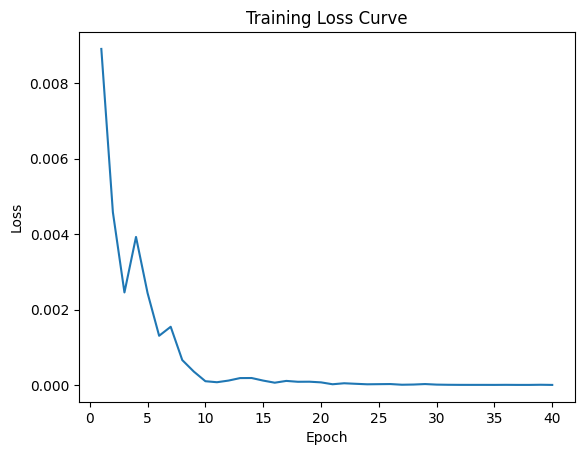

In [36]:
import matplotlib.pyplot as plt

plt.plot(range(1, epochs+1), losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

# 6. Evaluate Model

In [37]:
from sklearn.metrics import r2_score, mean_squared_error

def evaluate_regression_r2score():
    model.eval()
    
    y_true_train, y_pred_train = [], []
    y_true_test, y_pred_test = [], []
    
    with torch.no_grad():
        for batch_features, batch_labels in train_dataloader:
                batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
                preds =  model(batch_features).detach().cpu().numpy()
                y_pred_train.extend(preds)
                y_true_train.extend(batch_labels.cpu().numpy())
            
    with torch.no_grad():
        for batch_features, batch_labels in test_dataloader:
                batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
                preds =  model(batch_features).detach().cpu().numpy()
                y_pred_test.extend(preds)
                y_true_test.extend(batch_labels.cpu().numpy())
            
    # Convert to numpy arrays
    y_true_train = np.array(y_true_train)
    y_pred_train = np.array(y_pred_train)
    y_true_test = np.array(y_true_test)
    y_pred_test = np.array(y_pred_test)
                
    train_mse = mean_squared_error(y_true_train, y_pred_train)
    test_mse = mean_squared_error(y_true_test, y_pred_test)
            
    train_r2 = r2_score(y_true_train, y_pred_train)
    test_r2 = r2_score(y_true_test, y_pred_test)
    
    return {
        "Train MSE": train_mse,
        "Test MSE": test_mse,
        "Train R2": train_r2,
        "Test R2": test_r2
    }

In [38]:
evaluate_regression_r2score()

{'Train MSE': 7.212528089439729e-06,
 'Test MSE': 7.497624210373033e-06,
 'Train R2': 0.0,
 'Test R2': 0.0}